In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import scipy
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Short Study of Titanic_train dataset

## Objectives:  
1) Study of correlation between ticket prices and the age of passengers.  
2) Study of dependence between the gender of passengers and the fact their survival.  
**additionally:**  
3) Study of dependence between the gender of passengers and their ticket prices.


Save train_dataset to df and display first ten rows.

In [2]:
# save train_dataset to df and display first ten rows

df = pd.read_csv('/kaggle/input/titanic/train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Display main info about dataset.

In [3]:
# display main info about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Objective 1

Study of correlation between ticket prices and the age of passengers.

Display 'Age' histogram to check Gaussian distibution

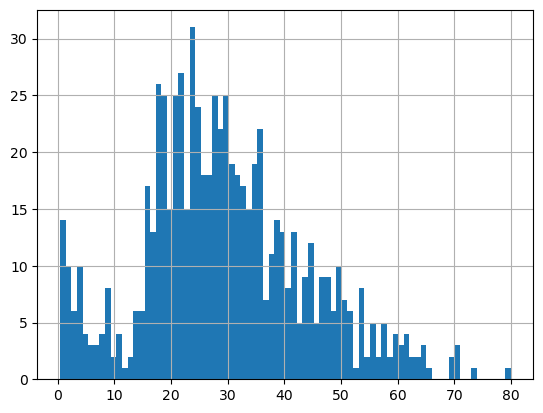

In [4]:
# display 'Age' histogram to check Gaussian distibution

df.Age.hist(bins=80)
plt.show()

Display 'Fare' histogram to check Gaussian distibution.

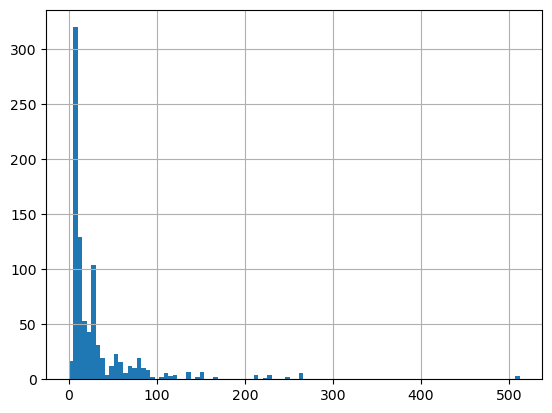

In [5]:
# display 'Fare' histogram to check Gaussian distibution

df.Fare.hist(bins=100)
plt.show()

There are zero values in Fare data. Let's check how many "zero" tickets we have.

In [6]:
df.loc[df.Fare == 0, 'Age'].count()

7

Only 7, but our chief came back and said there is no time to take care of it... )

Calculate correlation between Age and Fare and display scatterplot with regression line.

In [7]:
# calculate correlation between Age and Fare

cor = df.Age.corr(df.Fare, method='spearman').round(3)
cor

0.135

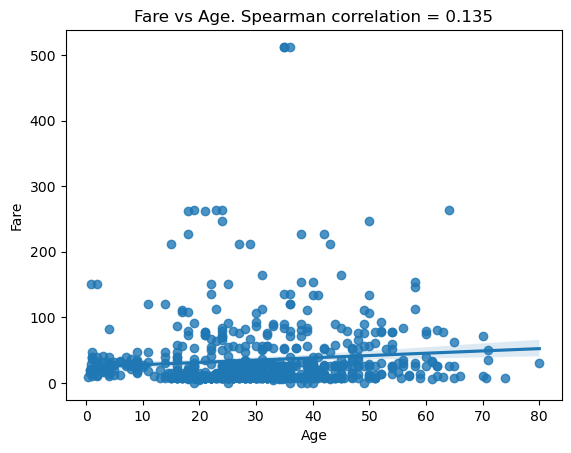

In [8]:
# display scatterplot with regression line

sns.regplot(data= df, x='Age', y='Fare')
plt.title(f'Fare vs Age. Spearman correlation = {cor}')
plt.show()

## Objective 2

Study of dependence between the gender of passengers and the fact their survival.

Display crosstab for two sets of the caterical data.

In [9]:
# display crosstab for two sets of the caterical data

pd.crosstab(df.Sex,df.Survived)

Survived,0,1
Sex,,
female,81,233
male,468,109


**Hypothesis:**  
H0: Gender and Survived are independent  
H1: Gender and Survived are dependent

To check hypothesis we use Chi Squared test

In [10]:
# to check hypothesis we use Chi Squared test
from scipy.stats import chi2_contingency
table = pd.crosstab(df.Sex,df.Survived)
stat, p, dof, expected = chi2_contingency(table)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
 print('Probably independent')
else:
 print('Probably dependent')

stat=260.717, p=0.000
Probably dependent


Compare result from dataset with expected result in an independent case

In [11]:
# compare result from dataset with expected result in an independent case

print(expected)
pd.crosstab(df.Sex,df.Survived)

[[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


Survived,0,1
Sex,,
female,81,233
male,468,109


Display barplot with percentage of survived passengers

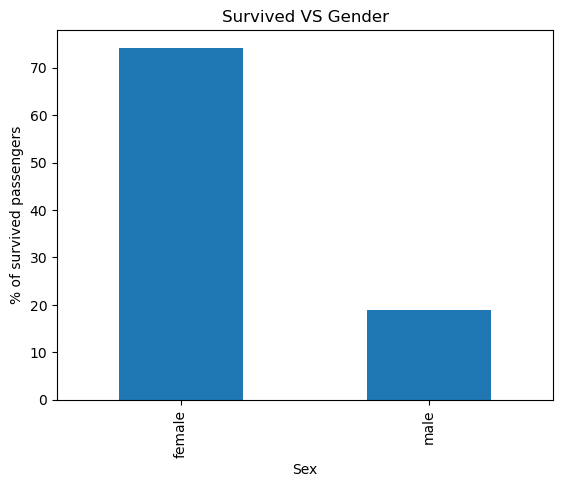

In [12]:
# display barplot with percentage of survived passengers

(df.groupby('Sex')['Survived'].agg('mean')*100).plot(
    kind='bar', 
    title='Survived VS Gender', 
    ylabel='% of survived passengers')
plt.show()

A little bit in another way...

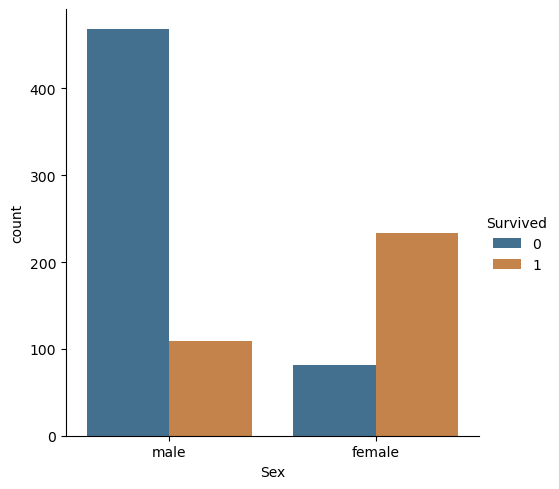

In [13]:
# little bit in another way...

sns.catplot(data=df, 
            hue='Survived',
            x='Sex', 
            kind='count',
            saturation=0.5);

## Objective 3

Study of dependence between the gender of passengers and their ticket prices.

Display mean ticket prices for different genders

In [14]:
# display mean ticket prices for different genders

df.groupby('Sex')['Fare'].agg('mean')

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64

**Hypothesis:**  
H0: Distribution of ticket prices for male and women are equal.  
H1: Distribution of ticket prices for male and women are not equal.  

Because we do not know is the data are iid (and also we have no time to check it), we run Mann-Whitney U test

In [15]:
# Because we do not know is the data are iid (and also we have no time to check it), 
# we run Mann-Whitney U test

stat, p = scipy.stats.mannwhitneyu(df.loc[df.Sex == 'male','Fare'], df.loc[df.Sex != 'male','Fare'])
print(f'stat={stat:.3f}, p={p:.3f}')
if p > 0.05: 
    print('There is no credible reason to reject H0')
else:
    print('There are enough reasons to reject H0, so we take H1')

stat=62175.000, p=0.000
There are enough reasons to reject H0, so we take H1


## Results:
- there is no correlation between ticket prices and Age of the passengers;
- gender of the passengers and their survival are depend;
- distribution of ticket prices for male and women are not equal.